In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
from src.imports import *

df = pd.read_pickle('../output/ch1/dataset_lcforest_noLOF_bin15_th3_80m_1kmsmallbox_noprior_ta_dw1_v7.pkl')
df['Eg_strong'] = np.where((df['beam_str'] == 'strong')&(df['outlier'] == 1), df['Eg'], np.nan)
df['Ev_strong'] = np.where((df['beam_str'] == 'strong')&(df['outlier'] == 1), df['Ev'], np.nan)
df['Eg_weak'] = np.where((df['beam_str'] == 'weak')&(df['outlier'] == 1), df['Eg'], np.nan)
df['Ev_weak'] = np.where((df['beam_str'] == 'weak')&(df['outlier'] == 1), df['Ev'], np.nan)
df['forest_type'] = np.where(df['segment_landcover']<119, 'closed', 'open')

df_grouped = df.groupby(['camera','date','lat','lon']).agg({
    'pvpg': 'mean',
    'pv': 'max',
    'pg': 'max',
    'Eg_strong': 'median',
    'Ev_strong': 'median',
    'Eg_weak': 'median',
    'Ev_weak': 'median',
    'data_quantity': 'max',
    'snr': 'mean',
    'FSC': 'mean',
    'TreeSnow': 'mean',
    'layer_flag': 'mean',
    'file_index': 'mean',
    'msw_flag': 'mean',
    'pv_ratio_mean': 'mean',
    'pv_ratio_max': 'mean',
    'forest_type': lambda x: pd.Series.mode(x).iloc[0],
}).reset_index()
df_grouped['JointSnow'] = df_grouped['FSC'] + df_grouped['TreeSnow']

data = df_grouped[((df_grouped['FSC'] <= 0.005)|(df_grouped['FSC'] >= 0.995))
    &((df_grouped['TreeSnow'] == 0)|(df_grouped['TreeSnow'] == 1))
    &(df_grouped['Eg_strong']/df_grouped['Eg_weak'] >= 1.15)
    &(df_grouped['data_quantity'] >= 26)]
data.loc[:, 'JointSnow'] = data['JointSnow'].apply(lambda x: np.round(x))
data["Conditions"] = data["JointSnow"].map({0: "No Snow", 1: "Ground Snow", 2: "Ground and Canopy Snow"})

/tmp/ipykernel_1446476/2875583580.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Conditions"] = data["JointSnow"].map({0: "No Snow", 1: "Ground Snow", 2: "Ground and Canopy Snow"})


Bootstrap fit 0/10000
Bootstrap fit 100/10000
Bootstrap fit 200/10000
Bootstrap fit 300/10000
Bootstrap fit 400/10000
Bootstrap fit 500/10000
Bootstrap fit 600/10000
Bootstrap fit 700/10000
Bootstrap fit 800/10000
Bootstrap fit 900/10000
Bootstrap fit 1000/10000
Bootstrap fit 1100/10000
Bootstrap fit 1200/10000
Bootstrap fit 1300/10000
Bootstrap fit 1400/10000
Bootstrap fit 1500/10000
Bootstrap fit 1600/10000
Bootstrap fit 1700/10000
Bootstrap fit 1800/10000
Bootstrap fit 1900/10000
Bootstrap fit 2000/10000
Bootstrap fit 2100/10000
Bootstrap fit 2200/10000
Bootstrap fit 2300/10000
Bootstrap fit 2400/10000
Bootstrap fit 2500/10000
Bootstrap fit 2600/10000
Bootstrap fit 2700/10000
Bootstrap fit 2800/10000
Bootstrap fit 2900/10000
Bootstrap fit 3000/10000
Bootstrap fit 3100/10000
Bootstrap fit 3200/10000
Bootstrap fit 3300/10000
Bootstrap fit 3400/10000
Bootstrap fit 3500/10000
Bootstrap fit 3600/10000
Bootstrap fit 3700/10000
Bootstrap fit 3800/10000
Bootstrap fit 3900/10000
Bootstrap fi

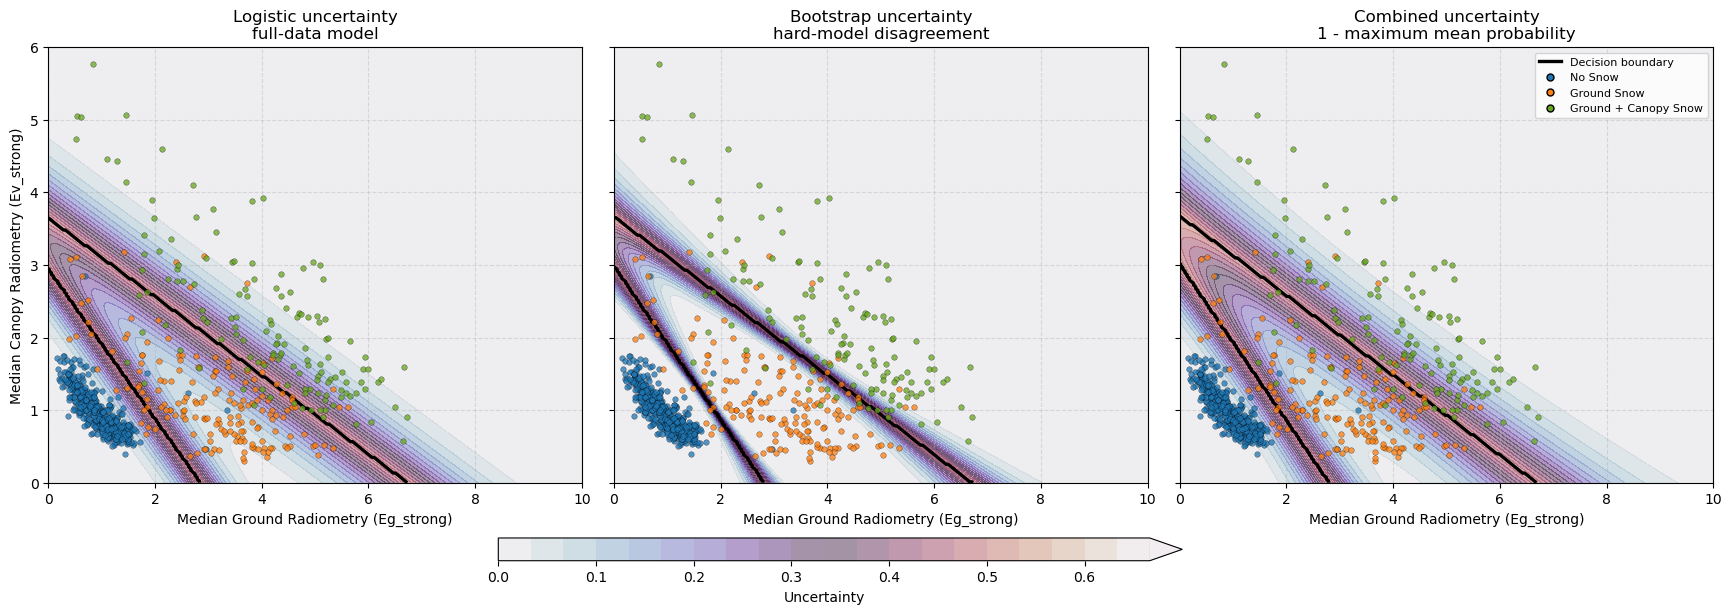

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from pathlib import Path
from sklearn.linear_model import LogisticRegression


# ============================================================
# SETTINGS
# ============================================================

N_BOOT = 10_000
RANDOM_SEED = 42

EG_COL = "Eg_strong"
EV_COL = "Ev_strong"
CLASS_COL = "JointSnow"
GROUP_COL = "camera"

CLASS_VALUES = np.array([0, 1, 2], dtype=int)

CLASS_LABELS = {
    0: "No Snow",
    1: "Ground Snow",
    2: "Ground + Canopy Snow",
}

POINT_COLORS = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#66a61e",
}

PLOT_XLIM = (0, 10)
PLOT_YLIM = (0, 6)
PLOT_GRID_N = 250

EXPORT_XLIM = (0, 16)
EXPORT_YLIM = (0, 16)
EXPORT_GRID_N = 801  # 0.02 spacing across 0--16

OUTPUT_NC = Path("../output/classification_uncertainty_EgEv.nc")

# These control only memory use while evaluating the bootstrap ensemble.
# They do not change the result.
POINT_CHUNK_SIZE = 10_000
MODEL_BATCH_SIZE = 100


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def make_logistic_model():
    return LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=0,
    )


def align_probabilities(probabilities, model_classes):
    """Return probability columns in the fixed order [0, 1, 2]."""
    aligned = np.zeros(
        (len(probabilities), len(CLASS_VALUES)),
        dtype=np.float64,
    )

    for source_column, class_value in enumerate(model_classes):
        target_column = np.where(CLASS_VALUES == int(class_value))[0][0]
        aligned[:, target_column] = probabilities[:, source_column]

    return aligned


def fixed_model_surfaces(model, grid_X):
    """Predictions and uncertainty from the one model fitted to all data."""
    probabilities = align_probabilities(
        model.predict_proba(grid_X),
        model.classes_,
    )

    predicted_class = CLASS_VALUES[np.argmax(probabilities, axis=1)]
    uncertainty = 1.0 - np.max(probabilities, axis=1)

    return probabilities, predicted_class, uncertainty


def evaluate_bootstrap_ensemble(
    grid_X,
    bootstrap_coefs,
    bootstrap_intercepts,
    point_chunk_size=POINT_CHUNK_SIZE,
    model_batch_size=MODEL_BATCH_SIZE,
):
    """
    Evaluate all bootstrap logistic models without storing every model/grid
    probability in memory.

    The combined predictive distribution is the mean of the bootstrap models'
    probability distributions:

        combined_probability(class k) = mean_b[p_b(class k)]

    The final class and combined uncertainty both come from this same
    distribution, so they are internally consistent.
    """
    bootstrap_coefs = np.asarray(bootstrap_coefs, dtype=np.float64)
    bootstrap_intercepts = np.asarray(bootstrap_intercepts, dtype=np.float64)

    n_models = len(bootstrap_coefs)
    n_points = len(grid_X)
    n_classes = len(CLASS_VALUES)

    if n_models == 0:
        raise RuntimeError("No valid bootstrap models were fitted.")

    mean_probabilities = np.zeros((n_points, n_classes), dtype=np.float64)
    vote_counts = np.zeros((n_points, n_classes), dtype=np.int32)
    expected_entropy = np.zeros(n_points, dtype=np.float64)
    expected_fixed_model_uncertainty = np.zeros(n_points, dtype=np.float64)

    for point_start in range(0, n_points, point_chunk_size):
        point_stop = min(point_start + point_chunk_size, n_points)
        X_chunk = np.asarray(
            grid_X[point_start:point_stop],
            dtype=np.float64,
        )

        probability_sum = np.zeros(
            (len(X_chunk), n_classes),
            dtype=np.float64,
        )
        entropy_sum = np.zeros(len(X_chunk), dtype=np.float64)
        model_uncertainty_sum = np.zeros(len(X_chunk), dtype=np.float64)
        chunk_vote_counts = np.zeros(
            (len(X_chunk), n_classes),
            dtype=np.int32,
        )

        for model_start in range(0, n_models, model_batch_size):
            model_stop = min(model_start + model_batch_size, n_models)

            coefs = bootstrap_coefs[model_start:model_stop]
            intercepts = bootstrap_intercepts[model_start:model_stop]

            # Shape: [model, point, class]
            scores = np.einsum(
                "mcf,nf->mnc",
                coefs,
                X_chunk,
                optimize=True,
            )
            scores += intercepts[:, None, :]

            # Stable softmax.
            scores -= np.max(scores, axis=2, keepdims=True)
            np.exp(scores, out=scores)
            probabilities = scores / np.sum(scores, axis=2, keepdims=True)

            probability_sum += np.sum(probabilities, axis=0)

            entropy_sum += np.sum(
                -np.sum(
                    probabilities * np.log(np.clip(probabilities, 1e-15, 1.0)),
                    axis=2,
                ),
                axis=0,
            )

            model_uncertainty_sum += np.sum(
                1.0 - np.max(probabilities, axis=2),
                axis=0,
            )

            model_predictions = np.argmax(probabilities, axis=2)
            for class_index in range(n_classes):
                chunk_vote_counts[:, class_index] += np.sum(
                    model_predictions == class_index,
                    axis=0,
                )

        point_slice = slice(point_start, point_stop)
        mean_probabilities[point_slice] = probability_sum / n_models
        vote_counts[point_slice] = chunk_vote_counts
        expected_entropy[point_slice] = entropy_sum / n_models
        expected_fixed_model_uncertainty[point_slice] = (
            model_uncertainty_sum / n_models
        )

    # Hard-vote disagreement: boundary-placement diagnostic.
    bootstrap_agreement = np.max(vote_counts, axis=1) / n_models
    bootstrap_uncertainty = 1.0 - bootstrap_agreement
    bootstrap_majority_class = CLASS_VALUES[np.argmax(vote_counts, axis=1)]

    # Final prediction and single combined uncertainty.
    combined_predicted_class = CLASS_VALUES[
        np.argmax(mean_probabilities, axis=1)
    ]
    predicted_class_probability = np.max(mean_probabilities, axis=1)
    combined_uncertainty = 1.0 - predicted_class_probability

    # Entropy decomposition retained as additional diagnostics.
    predictive_entropy = -np.sum(
        mean_probabilities
        * np.log(np.clip(mean_probabilities, 1e-15, 1.0)),
        axis=1,
    )
    epistemic_mutual_information = np.maximum(
        predictive_entropy - expected_entropy,
        0.0,
    )

    entropy_scale = np.log(n_classes)

    return {
        "probabilities": mean_probabilities,
        "predicted_class": combined_predicted_class,
        "predicted_class_probability": predicted_class_probability,
        "combined_uncertainty": combined_uncertainty,
        "bootstrap_majority_class": bootstrap_majority_class,
        "bootstrap_agreement": bootstrap_agreement,
        "bootstrap_uncertainty": bootstrap_uncertainty,
        "expected_logistic_uncertainty": expected_fixed_model_uncertainty,
        "predictive_entropy": predictive_entropy / entropy_scale,
        "expected_entropy": expected_entropy / entropy_scale,
        "epistemic_mutual_information": (
            epistemic_mutual_information / entropy_scale
        ),
    }


def reshape_surface(values, grid_shape):
    """Reshape point-wise results back onto [Ev, Eg]."""
    values = np.asarray(values)

    if values.ndim == 1:
        return values.reshape(grid_shape)

    if values.ndim == 2:
        return values.reshape(*grid_shape, values.shape[1])

    raise ValueError("Expected a one- or two-dimensional array.")


def classify_new_data(new_data, uncertainty_dataset):
    """
    Classify another DataFrame by interpolating the combined probability
    surfaces in the saved NetCDF file.

    Values outside the exported Eg/Ev range receive NaN.
    """
    query_eg = xr.DataArray(
        new_data[EG_COL].to_numpy(),
        dims="observation",
    )
    query_ev = xr.DataArray(
        new_data[EV_COL].to_numpy(),
        dims="observation",
    )

    probabilities = np.column_stack([
        uncertainty_dataset["prob_no_snow"].interp(
            {EG_COL: query_eg, EV_COL: query_ev}
        ).values,
        uncertainty_dataset["prob_ground_snow"].interp(
            {EG_COL: query_eg, EV_COL: query_ev}
        ).values,
        uncertainty_dataset["prob_ground_canopy_snow"].interp(
            {EG_COL: query_eg, EV_COL: query_ev}
        ).values,
    ])

    result = new_data.copy()
    valid = np.all(np.isfinite(probabilities), axis=1)

    result["predicted_class"] = pd.array(
        np.full(len(result), np.nan),
        dtype="Int8",
    )
    result["classification_probability"] = np.nan
    result["classification_uncertainty"] = np.nan

    if np.any(valid):
        valid_probabilities = probabilities[valid]
        predicted_indices = np.argmax(valid_probabilities, axis=1)
        predicted_classes = CLASS_VALUES[predicted_indices]
        predicted_probabilities = np.max(valid_probabilities, axis=1)

        result.loc[valid, "predicted_class"] = predicted_classes
        result.loc[valid, "classification_probability"] = (
            predicted_probabilities
        )
        result.loc[valid, "classification_uncertainty"] = (
            1.0 - predicted_probabilities
        )

    return result


# ============================================================
# PREPARE DATA
# ============================================================

try:
    data
except NameError as error:
    raise NameError(
        "This script expects the input pandas DataFrame to be named 'data'."
    ) from error

required_columns = [EG_COL, EV_COL, CLASS_COL, GROUP_COL]
missing_columns = [column for column in required_columns if column not in data]

if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

plot_df = data.dropna(subset=required_columns).copy()
plot_df[CLASS_COL] = plot_df[CLASS_COL].astype(int)

observed_classes = set(plot_df[CLASS_COL].unique())
if observed_classes != set(CLASS_VALUES):
    raise ValueError(
        f"Expected classes {set(CLASS_VALUES)}, found {observed_classes}."
    )

all_cameras = np.sort(plot_df[GROUP_COL].unique())
rng = np.random.default_rng(RANDOM_SEED)


# ============================================================
# FIT THE ONE MODEL USING ALL DATA
# ============================================================

full_model = make_logistic_model()
full_model.fit(
    plot_df[[EG_COL, EV_COL]].to_numpy(),
    plot_df[CLASS_COL].to_numpy(),
)


# ============================================================
# FIT CAMERA-LEVEL BOOTSTRAP MODELS
# ============================================================

bootstrap_coefs = []
bootstrap_intercepts = []

camera_frames = {
    camera: frame
    for camera, frame in plot_df.groupby(GROUP_COL, sort=False)
}

for bootstrap_number in range(N_BOOT):
    if bootstrap_number % 100 == 0:
        print(f"Bootstrap fit {bootstrap_number}/{N_BOOT}")

    sampled_cameras = rng.choice(
        all_cameras,
        size=len(all_cameras),
        replace=True,
    )

    bootstrap_df = pd.concat(
        [camera_frames[camera] for camera in sampled_cameras],
        ignore_index=True,
    )

    if set(bootstrap_df[CLASS_COL].unique()) != set(CLASS_VALUES):
        continue

    bootstrap_model = make_logistic_model()
    bootstrap_model.fit(
        bootstrap_df[[EG_COL, EV_COL]].to_numpy(),
        bootstrap_df[CLASS_COL].to_numpy(),
    )

    # All valid models contain classes [0, 1, 2], but align explicitly.
    class_order = [
        list(bootstrap_model.classes_).index(class_value)
        for class_value in CLASS_VALUES
    ]

    bootstrap_coefs.append(bootstrap_model.coef_[class_order])
    bootstrap_intercepts.append(bootstrap_model.intercept_[class_order])

bootstrap_coefs = np.asarray(bootstrap_coefs)
bootstrap_intercepts = np.asarray(bootstrap_intercepts)
n_valid_boot = len(bootstrap_coefs)

if n_valid_boot == 0:
    raise RuntimeError("None of the bootstrap samples contained all classes.")

print(f"Valid bootstrap models: {n_valid_boot}/{N_BOOT}")


# ============================================================
# CREATE PLOTTING SURFACES
# ============================================================

plot_x_grid = np.linspace(*PLOT_XLIM, PLOT_GRID_N)
plot_y_grid = np.linspace(*PLOT_YLIM, PLOT_GRID_N)
plot_xx, plot_yy = np.meshgrid(plot_x_grid, plot_y_grid)
plot_grid_X = np.column_stack([plot_xx.ravel(), plot_yy.ravel()])

(
    plot_full_probabilities,
    plot_full_predicted_class,
    plot_logistic_uncertainty,
) = fixed_model_surfaces(full_model, plot_grid_X)

plot_ensemble = evaluate_bootstrap_ensemble(
    plot_grid_X,
    bootstrap_coefs,
    bootstrap_intercepts,
)

plot_full_predicted_class = reshape_surface(
    plot_full_predicted_class,
    plot_xx.shape,
)
plot_logistic_uncertainty = reshape_surface(
    plot_logistic_uncertainty,
    plot_xx.shape,
)
plot_bootstrap_majority_class = reshape_surface(
    plot_ensemble["bootstrap_majority_class"],
    plot_xx.shape,
)
plot_bootstrap_uncertainty = reshape_surface(
    plot_ensemble["bootstrap_uncertainty"],
    plot_xx.shape,
)
plot_combined_predicted_class = reshape_surface(
    plot_ensemble["predicted_class"],
    plot_xx.shape,
)
plot_combined_uncertainty = reshape_surface(
    plot_ensemble["combined_uncertainty"],
    plot_xx.shape,
)


# ============================================================
# PLOT ALL THREE UNCERTAINTY SURFACES
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6.5),
    sharex=True,
    sharey=True,
)

fig.subplots_adjust(
    left=0.06,
    right=0.985,
    top=0.87,
    bottom=0.20,
    wspace=0.06,
)

plot_specs = [
    (
        axes[0],
        plot_logistic_uncertainty,
        plot_full_predicted_class,
        "Logistic uncertainty\nfull-data model",
    ),
    (
        axes[1],
        plot_bootstrap_uncertainty,
        plot_bootstrap_majority_class,
        "Bootstrap uncertainty\nhard-model disagreement",
    ),
    (
        axes[2],
        plot_combined_uncertainty,
        plot_combined_predicted_class,
        "Combined uncertainty\n1 - maximum mean probability",
    ),
]

uncertainty_levels = np.linspace(0, 2 / 3, 21)

for ax, uncertainty, predicted_class, title in plot_specs:
    image = ax.contourf(
        plot_xx,
        plot_yy,
        uncertainty,
        levels=uncertainty_levels,
        cmap="twilight",
        alpha=0.45,
        extend="max",
    )

    # These are the actual decision boundaries for the model represented in
    # this panel, rather than a line made from median slopes/intercepts.
    ax.contour(
        plot_xx,
        plot_yy,
        predicted_class,
        levels=[0.5, 1.5],
        colors="black",
        linewidths=2.4,
    )

    for class_value in CLASS_VALUES:
        class_mask = plot_df[CLASS_COL] == class_value
        ax.scatter(
            plot_df.loc[class_mask, EG_COL],
            plot_df.loc[class_mask, EV_COL],
            s=16,
            alpha=0.75,
            color=POINT_COLORS[class_value],
            edgecolors="black",
            linewidths=0.25,
            zorder=4,
            label=CLASS_LABELS[class_value],
        )

    ax.set_title(title)
    ax.set_xlabel(f"Median Ground Radiometry ({EG_COL})")
    ax.set_xlim(*PLOT_XLIM)
    ax.set_ylim(*PLOT_YLIM)
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel(f"Median Canopy Radiometry ({EV_COL})")

colorbar_axis = fig.add_axes([0.31, 0.08, 0.38, 0.035])
colorbar = fig.colorbar(
    image,
    cax=colorbar_axis,
    orientation="horizontal",
)
colorbar.set_label("Uncertainty")

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        color="black",
        lw=2.4,
        label="Decision boundary",
    ),
]

for class_value in CLASS_VALUES:
    legend_handles.append(
        plt.Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=POINT_COLORS[class_value],
            markeredgecolor="black",
            markersize=5,
            label=CLASS_LABELS[class_value],
        )
    )

axes[2].legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=8,
    frameon=True,
)

plt.show()


# ============================================================
# EVALUATE AND EXPORT THE FULL 0--16 GRID
# ============================================================

export_x_grid = np.linspace(*EXPORT_XLIM, EXPORT_GRID_N)
export_y_grid = np.linspace(*EXPORT_YLIM, EXPORT_GRID_N)
export_xx, export_yy = np.meshgrid(export_x_grid, export_y_grid)
export_grid_X = np.column_stack([export_xx.ravel(), export_yy.ravel()])

(
    export_full_probabilities,
    export_full_predicted_class,
    export_logistic_uncertainty,
) = fixed_model_surfaces(full_model, export_grid_X)

# print("Evaluating bootstrap ensemble on export grid...")
# export_ensemble = evaluate_bootstrap_ensemble(
#     export_grid_X,
#     bootstrap_coefs,
#     bootstrap_intercepts,
# )

# grid_shape = export_xx.shape

# combined_probabilities = reshape_surface(
#     export_ensemble["probabilities"],
#     grid_shape,
# )


# # ============================================================
# # BUILD AND SAVE NETCDF
# # ============================================================
# print('Building netcdf')
# ds_uncertainty = xr.Dataset(
#     data_vars={
#         # Final outputs to use when classifying other data.
#         "predicted_class": (
#             [EV_COL, EG_COL],
#             reshape_surface(
#                 export_ensemble["predicted_class"],
#                 grid_shape,
#             ).astype("int8"),
#         ),
#         "predicted_class_probability": (
#             [EV_COL, EG_COL],
#             reshape_surface(
#                 export_ensemble["predicted_class_probability"],
#                 grid_shape,
#             ).astype("float32"),
#         ),
#         "combined_uncertainty": (
#             [EV_COL, EG_COL],
#             reshape_surface(
#                 export_ensemble["combined_uncertainty"],
#                 grid_shape,
#             ).astype("float32"),
#         ),
#         "prob_no_snow": (
#             [EV_COL, EG_COL],
#             combined_probabilities[:, :, 0].astype("float32"),
#         ),
#         "prob_ground_snow": (
#             [EV_COL, EG_COL],
#             combined_probabilities[:, :, 1].astype("float32"),
#         ),
#         "prob_ground_canopy_snow": (
#             [EV_COL, EG_COL],
#             combined_probabilities[:, :, 2].astype("float32"),
#         ),

#         # Separate diagnostic uncertainties.
#         "logistic_uncertainty": (
#             [EV_COL, EG_COL],
#             reshape_surface(
#                 export_logistic_uncertainty,
#                 grid_shape,
#             ).astype("float32"),
#         ),
#         "bootstrap_uncertainty": (
#             [EV_COL, EG_COL],
#             reshape_surface(
#                 export_ensemble["bootstrap_uncertainty"],
#                 grid_shape,
#             ).astype("float32"),
#         ),
#         "bootstrap_agreement": (
#             [EV_COL, EG_COL],
#             reshape_surface(
#                 export_ensemble["bootstrap_agreement"],
#                 grid_shape,
#             ).astype("float32"),
#         ),
#         "expected_logistic_uncertainty": (
#             [EV_COL, EG_COL],
#             reshape_surface(
#                 export_ensemble["expected_logistic_uncertainty"],
#                 grid_shape,
#             ).astype("float32"),
#         ),

#         # Normalized entropy decomposition. These are useful diagnostics, but
#         # combined_uncertainty remains the requested single uncertainty value.
#         "predictive_entropy": (
#             [EV_COL, EG_COL],
#             reshape_surface(
#                 export_ensemble["predictive_entropy"],
#                 grid_shape,
#             ).astype("float32"),
#         ),
#         "expected_entropy": (
#             [EV_COL, EG_COL],
#             reshape_surface(
#                 export_ensemble["expected_entropy"],
#                 grid_shape,
#             ).astype("float32"),
#         ),
#         "epistemic_mutual_information": (
#             [EV_COL, EG_COL],
#             reshape_surface(
#                 export_ensemble["epistemic_mutual_information"],
#                 grid_shape,
#             ).astype("float32"),
#         ),

#         # Fixed full-data model prediction retained for comparison only.
#         "full_model_predicted_class": (
#             [EV_COL, EG_COL],
#             reshape_surface(
#                 export_full_predicted_class,
#                 grid_shape,
#             ).astype("int8"),
#         ),

#         # Bootstrap model parameters allow exact ensemble predictions later,
#         # without reducing the ensemble to median boundary coefficients.
#         "bootstrap_coef": (
#             ["bootstrap", "class", "feature"],
#             bootstrap_coefs.astype("float32"),
#         ),
#         "bootstrap_intercept": (
#             ["bootstrap", "class"],
#             bootstrap_intercepts.astype("float32"),
#         ),
#         "full_model_coef": (
#             ["class", "feature"],
#             full_model.coef_.astype("float32"),
#         ),
#         "full_model_intercept": (
#             ["class"],
#             full_model.intercept_.astype("float32"),
#         ),
#     },
#     coords={
#         EG_COL: export_x_grid.astype("float32"),
#         EV_COL: export_y_grid.astype("float32"),
#         "bootstrap": np.arange(n_valid_boot, dtype="int32"),
#         "class": CLASS_VALUES.astype("int8"),
#         "feature": np.array([EG_COL, EV_COL], dtype=str),
#     },
#     attrs={
#         "description": (
#             "Three-class logistic-regression predictive uncertainty surface "
#             "with camera-level bootstrap model averaging"
#         ),
#         "final_classification": (
#             "argmax of the mean bootstrap class probabilities"
#         ),
#         "combined_uncertainty_definition": (
#             "1 - maximum mean bootstrap class probability"
#         ),
#         "combined_uncertainty_interpretation": (
#             "estimated probability that the selected class is wrong, "
#             "provided the probabilities are calibrated"
#         ),
#         "logistic_uncertainty_definition": (
#             "1 - maximum probability from the single full-data model"
#         ),
#         "bootstrap_uncertainty_definition": (
#             "1 - fraction of bootstrap models voting for the modal class"
#         ),
#         "entropy_normalization": "divided by log(3), so range is 0--1",
#         "bootstrap_unit": GROUP_COL,
#         "n_requested_bootstraps": N_BOOT,
#         "n_valid_bootstraps": n_valid_boot,
#         "random_seed": RANDOM_SEED,
#         "model": "sklearn LogisticRegression, lbfgs, default L2 penalty",
#         "Eg_column": EG_COL,
#         "Ev_column": EV_COL,
#         "class_column": CLASS_COL,
#         "class_0": CLASS_LABELS[0],
#         "class_1": CLASS_LABELS[1],
#         "class_2": CLASS_LABELS[2],
#         "x_range": str(EXPORT_XLIM),
#         "y_range": str(EXPORT_YLIM),
#         "grid_n": EXPORT_GRID_N,
#     },
# )

# variable_attributes = {
#     "predicted_class": {
#         "long_name": "final combined predicted class",
#         "flag_values": CLASS_VALUES.astype("int8"),
#         "flag_meanings": "no_snow ground_snow ground_and_canopy_snow",
#     },
#     "predicted_class_probability": {
#         "long_name": "combined probability of the predicted class",
#         "valid_min": 1 / 3,
#         "valid_max": 1.0,
#     },
#     "combined_uncertainty": {
#         "long_name": "single total predictive classification uncertainty",
#         "valid_min": 0.0,
#         "valid_max": 2 / 3,
#     },
#     "logistic_uncertainty": {
#         "long_name": "fixed full-data logistic-model uncertainty",
#         "valid_min": 0.0,
#         "valid_max": 2 / 3,
#     },
#     "bootstrap_uncertainty": {
#         "long_name": "bootstrap hard-vote disagreement",
#         "valid_min": 0.0,
#         "valid_max": 2 / 3,
#     },
#     "bootstrap_agreement": {
#         "long_name": "largest bootstrap class vote fraction",
#         "valid_min": 1 / 3,
#         "valid_max": 1.0,
#     },
#     "expected_logistic_uncertainty": {
#         "long_name": "mean within-bootstrap-model uncertainty",
#         "valid_min": 0.0,
#         "valid_max": 2 / 3,
#     },
#     "predictive_entropy": {
#         "long_name": "normalized entropy of mean bootstrap probabilities",
#         "valid_min": 0.0,
#         "valid_max": 1.0,
#     },
#     "expected_entropy": {
#         "long_name": "normalized mean entropy within bootstrap models",
#         "valid_min": 0.0,
#         "valid_max": 1.0,
#     },
#     "epistemic_mutual_information": {
#         "long_name": "normalized entropy-based model uncertainty",
#         "valid_min": 0.0,
#         "valid_max": 1.0,
#     },
# }

# for variable_name, attributes in variable_attributes.items():
#     ds_uncertainty[variable_name].attrs.update(attributes)

# for variable_name in [
#     "prob_no_snow",
#     "prob_ground_snow",
#     "prob_ground_canopy_snow",
# ]:
#     ds_uncertainty[variable_name].attrs.update({
#         "long_name": "mean bootstrap predictive class probability",
#         "valid_min": 0.0,
#         "valid_max": 1.0,
#     })

# # OUTPUT_NC.parent.mkdir(parents=True, exist_ok=True)
# # ds_uncertainty.to_netcdf(OUTPUT_NC)

# # print(f"\nSaved NetCDF: {OUTPUT_NC.resolve()}")
# # print(ds_uncertainty)


# # Example for later use:
# #
# # with xr.open_dataset(OUTPUT_NC) as uncertainty_lookup:
# #     other_data_with_predictions = classify_new_data(
# #         other_data,
# #         uncertainty_lookup,
# #     )

In [12]:
ds_uncertainty#.combined_uncertainty.plot(xlim=(0,8),ylim=(0,6))

<xarray.Dataset> Size: 32MB
Dimensions:                        (Ev_strong: 801, Eg_strong: 801,
                                    bootstrap: 10000, class: 3, feature: 2)
Coordinates:
  * Eg_strong                      (Eg_strong) float32 3kB 0.0 0.02 ... 16.0
  * Ev_strong                      (Ev_strong) float32 3kB 0.0 0.02 ... 16.0
  * bootstrap                      (bootstrap) int32 40kB 0 1 2 ... 9998 9999
  * class                          (class) int8 3B 0 1 2
  * feature                        (feature) <U9 72B 'Eg_strong' 'Ev_strong'
Data variables: (12/18)
    predicted_class                (Ev_strong, Eg_strong) int8 642kB 0 0 ... 2 2
    predicted_class_probability    (Ev_strong, Eg_strong) float32 3MB 1.0 ......
    combined_uncertainty           (Ev_strong, Eg_strong) float32 3MB 2.661e-...
    prob_no_snow                   (Ev_strong, Eg_strong) float32 3MB 1.0 ......
    prob_ground_snow               (Ev_strong, Eg_strong) float32 3MB 2.661e-...
    prob_ground_canopy_snow        (Ev_strong, Eg_strong) float32 3MB 1.241e-...
    ...                             ...
    epistemic_mutual_information   (Ev_strong, Eg_strong) float32 3MB 1.766e-...
    full_model_predicted_class     (Ev_strong, Eg_strong) int8 642kB 0 0 ... 2 2
    bootstrap_coef                 (bootstrap, class, feature) float32 240kB ...
    bootstrap_intercept            (bootstrap, class) float32 120kB 10.36 ......
    full_model_coef                (class, feature) float32 24B -3.208 ... 3.326
    full_model_intercept           (class) float32 12B 11.29 -0.06761 -11.22
Attributes: (12/21)
    description:                          Three-class logistic-regression pre...
    final_classification:                 argmax of the mean bootstrap class ...
    combined_uncertainty_definition:      1 - maximum mean bootstrap class pr...
    combined_uncertainty_interpretation:  estimated probability that the sele...
    logistic_uncertainty_definition:      1 - maximum probability from the si...
    bootstrap_uncertainty_definition:     1 - fraction of bootstrap models vo...
    ...                                   ...
    class_0:                              No Snow
    class_1:                              Ground Snow
    class_2:                              Ground + Canopy Snow
    x_range:                              (0, 16)
    y_range:                              (0, 16)
    grid_n:                               801

In [15]:
OUTPUT_NC

PosixPath('../output/classification_uncertainty_EgEv.nc')

In [13]:
OUTPUT_NC.parent.mkdir(parents=True, exist_ok=True)
ds_uncertainty.to_netcdf(OUTPUT_NC)

print(f"\nSaved NetCDF: {OUTPUT_NC.resolve()}")
print(ds_uncertainty)


Saved NetCDF: /home/s1803229/Chapter_2/output/classification_uncertainty_EgEv.nc
<xarray.Dataset> Size: 32MB
Dimensions:                        (Ev_strong: 801, Eg_strong: 801,
                                    bootstrap: 10000, class: 3, feature: 2)
Coordinates:
  * Eg_strong                      (Eg_strong) float32 3kB 0.0 0.02 ... 16.0
  * Ev_strong                      (Ev_strong) float32 3kB 0.0 0.02 ... 16.0
  * bootstrap                      (bootstrap) int32 40kB 0 1 2 ... 9998 9999
  * class                          (class) int8 3B 0 1 2
  * feature                        (feature) <U9 72B 'Eg_strong' 'Ev_strong'
Data variables: (12/18)
    predicted_class                (Ev_strong, Eg_strong) int8 642kB 0 0 ... 2 2
    predicted_class_probability    (Ev_strong, Eg_strong) float32 3MB 1.0 ......
    combined_uncertainty           (Ev_strong, Eg_strong) float32 3MB 2.661e-...
    prob_no_snow                   (Ev_strong, Eg_strong) float32 3MB 1.0 ......
    prob_ground_sno